In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df=pd.read_csv(r"D:\__Projects\LangFlow-Classifier\Data\English\original\sentiment_data.csv")

In [30]:
df.duplicated().sum()

0

In [31]:
df

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2
...,...,...,...
241140,241921,crores paid neerav modi recovered congress lea...,0
241141,241922,dear rss terrorist payal gawar modi killing pl...,0
241142,241923,cover interaction forum left,1
241143,241924,big project came india modi dream project happ...,1


In [32]:
df.drop(columns=["Unnamed: 0"],inplace=True)

In [33]:
df

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2
...,...,...
241140,crores paid neerav modi recovered congress lea...,0
241141,dear rss terrorist payal gawar modi killing pl...,0
241142,cover interaction forum left,1
241143,big project came india modi dream project happ...,1


In [34]:
df["Sentiment"].value_counts()

Sentiment
2    103059
1     82972
0     55114
Name: count, dtype: int64

<Axes: xlabel='Sentiment', ylabel='Count'>

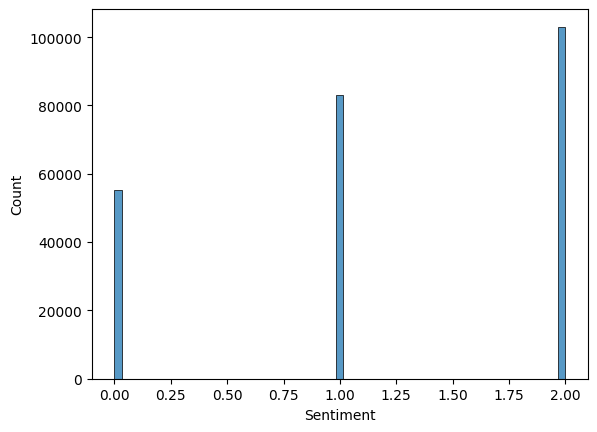

In [35]:
sns.histplot(df["Sentiment"])

In [36]:
df.isna().sum()

Comment      217
Sentiment      0
dtype: int64

In [37]:
df.duplicated().sum()

26809

In [38]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

count    214333.000000
mean         92.879976
std          73.324877
min           1.000000
25%          45.000000
50%          78.000000
75%         132.000000
max        5080.000000
Name: Comment, dtype: float64


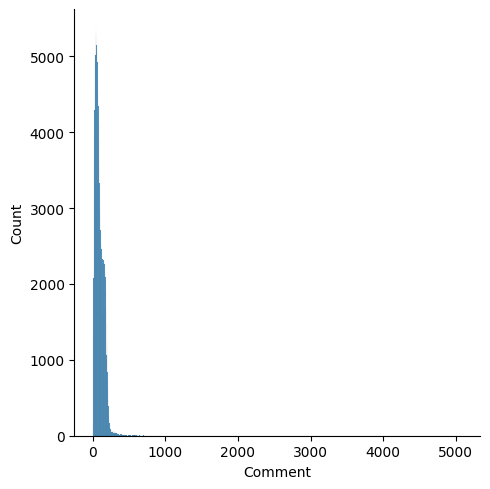

In [39]:
print(df["Comment"].str.len().describe())
sns.displot(df["Comment"].str.len())

In [40]:
df.loc[df["Comment"].str.len()<3]

,Comment,Sentiment
11590,哈哈,1
13129,go,2
16430,jó,1
19649,ok,1
21920,go,1
23077,em,0
23953,ok,2
24243,aw,1
25311,u,1
25568,xo,1


In [41]:
df=df.loc[df["Comment"].str.len()>3].copy()

<Axes: ylabel='Comment'>

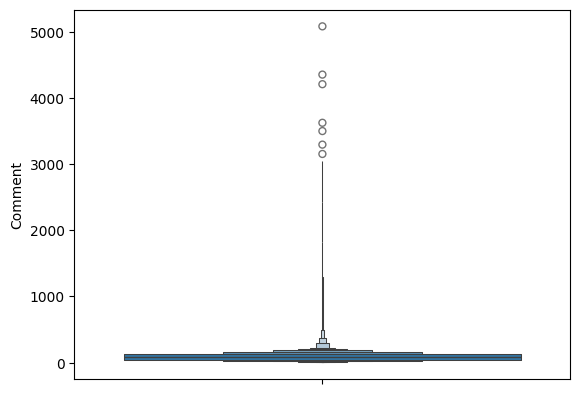

In [42]:
sns.boxenplot(df["Comment"].str.len())

In [43]:
df.loc[df["Comment"].str.len()>2000]

,Comment,Sentiment
2107,summary notes intro problem information overlo...,2
3974,timestamps took forever intro ——————————— orig...,1
5859,found sameone recent comment maybe discovered ...,1
5915,tell job interview mr davis ready interview th...,2
7161,transcript literature review essay research pa...,0
10162,underestanding wife wasnt going survive either...,0
10460,tracklist kanisan ft wishes dreams morning moo...,1
10948,estoy aprovechando de ti esta noche cazarte co...,1
11304,ive edtech consultant beijing years ive also t...,0
11331,found interesting someone adhdi lot hyperfocus...,2


In [44]:
df=df.loc[df["Comment"].str.len()<2000].copy()

In [45]:
from nltk.corpus import stopwords
stop_words= set(stopwords.words('english'))
import re
def clean_text(text):
    text= text.lower()
    text= re.sub(r'[^\w\s]', '', text)
    text=' '.join(word for word in text.split() if word not in stop_words)
    return text
df["text"]=df["Comment"].apply(clean_text)

In [46]:
df.to_csv(r"D:\__Projects\LangFlow-Classifier\Data\English\processed\sentiment_data_cleaned.csv",index=False)

In [47]:
df

,Comment,Sentiment,text
0,lets forget apple pay required brand new iphon...,1,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...,0,nz retailers dont even contactless credit card...
2,forever acknowledge channel help lessons ideas...,2,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...,0,whenever go place doesnt take apple pay doesnt...
4,apple pay convenient secure easy use used kore...,2,apple pay convenient secure easy use used kore...
...,...,...,...
241140,crores paid neerav modi recovered congress lea...,0,crores paid neerav modi recovered congress lea...
241141,dear rss terrorist payal gawar modi killing pl...,0,dear rss terrorist payal gawar modi killing pl...
241142,cover interaction forum left,1,cover interaction forum left
241143,big project came india modi dream project happ...,1,big project came india modi dream project happ...


In [48]:
def commom_word_per_label(df):
    for l in df["Sentiment"].unique():
        print(f"Sentiment: {l}")
        common_words = df[df["Sentiment"]==l]["text"].str.split(expand=True).stack().value_counts().head(5)
        print(common_words)
        print("-" * 50)
commom_word_per_label(df)

Sentiment: 1
modi        46046
india        6226
like         4475
narendra     3844
bjp          3759
Name: count, dtype: int64
--------------------------------------------------
Sentiment: 0
modi      33419
india      5908
like       4626
people     4509
bjp        3448
Name: count, dtype: int64
--------------------------------------------------
Sentiment: 2
modi      66820
india     14935
like       8634
people     7463
good       7367
Name: count, dtype: int64
--------------------------------------------------


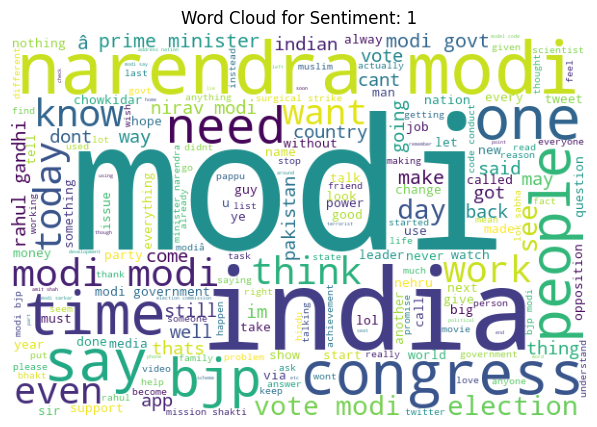

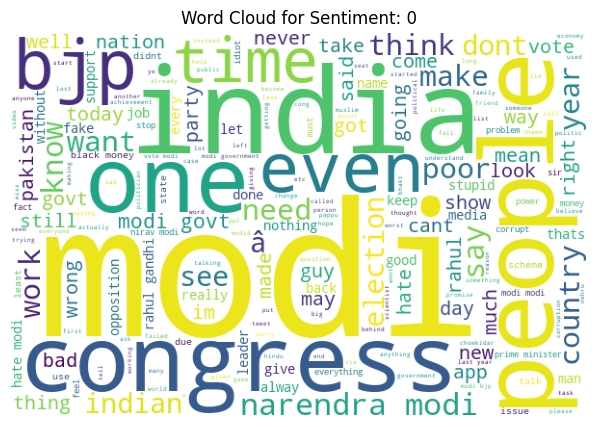

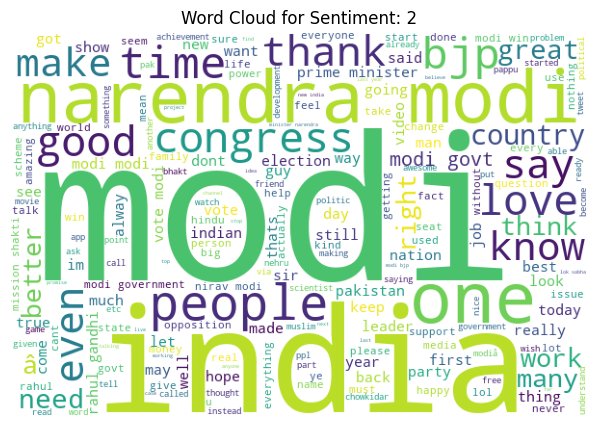

In [49]:
from wordcloud import WordCloud
for l in df["Sentiment"].unique():
    text = ' '.join(df[df["Sentiment"]==l]["text"])
    wordcloud = WordCloud(width=600, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title(f'Word Cloud for Sentiment: {l}')
    plt.show()

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
x=df["text"]
y=df["Sentiment"]
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
vectorizer=TfidfVectorizer(max_features=1000)
X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)

In [51]:
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()
gnb.fit(X_train_tfidf.toarray(),y_train)
y_pred=gnb.predict(X_test_tfidf.toarray())
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.49      0.57      0.53      9626
           1       0.57      0.76      0.66     14538
           2       0.80      0.53      0.64     18669

    accuracy                           0.62     42833
   macro avg       0.62      0.62      0.61     42833
weighted avg       0.65      0.62      0.62     42833



In [52]:
import joblib
joblib.dump(gnb,r"D:\__Projects\LangFlow-Classifier\models\english\english_sentiment_model.joblib")
joblib.dump(vectorizer,r"D:\__Projects\LangFlow-Classifier\models\english\english_vectorizer.joblib")

['D:\\__Projects\\LangFlow-Classifier\\models\\english\\english_vectorizer.joblib']